In [1]:
import torch
import matplotlib.pyplot as plt
import cv2

from VAE import VAE, vae_loss

from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from img_dataloader import dataset_imgs

from DiT import DiT
from Scheduler import DDPM

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
device = "cpu"

In [3]:
def train_vae(vae, dataloader, epochs=100):
    losses = []
    opt = torch.optim.Adam(vae.parameters(), lr=1e-4)

    step = 0

    for epoch in range(epochs):
        epoch_loss = 0
        for images, x_t, noise, t, number in dataloader:
            images = images.to(device)
            recon, mu, logvar = vae(images)

            # Anneal KL weight from 0 -> 1e-4 over first 10k steps
            # to avoid posterior collapse early in training
            kl_w = min(1e-4, step / epochs * 1e-4)
            loss = vae_loss(recon, images, mu, logvar, kl_weight=kl_w)
            epoch_loss += loss.item()

            opt.zero_grad()
            loss.backward()
            opt.step()

            step += 1
        
        losses.append(epoch_loss/len(dataloader))
        print(f"Epoch: {epoch} / {epochs} => loss: {epoch_loss/len(dataloader):.2f}")

In [4]:
dataset = dataset_imgs("Temp Dataset")
dataloader  = DataLoader(dataset, batch_size = 5, shuffle = True)

In [5]:
vae = VAE(ch = 128, latent_channels = 4)

In [50]:
losses = train_vae(vae, dataloader, epochs = 20)

Epoch: 0 / 20 => loss: 0.38
Epoch: 1 / 20 => loss: 0.09
Epoch: 2 / 20 => loss: 0.11
Epoch: 3 / 20 => loss: 0.07
Epoch: 4 / 20 => loss: 0.07
Epoch: 5 / 20 => loss: 0.06
Epoch: 6 / 20 => loss: 0.05
Epoch: 7 / 20 => loss: 0.05
Epoch: 8 / 20 => loss: 0.05
Epoch: 9 / 20 => loss: 0.05
Epoch: 10 / 20 => loss: 0.04
Epoch: 11 / 20 => loss: 0.04
Epoch: 12 / 20 => loss: 0.04
Epoch: 13 / 20 => loss: 0.04
Epoch: 14 / 20 => loss: 0.04
Epoch: 15 / 20 => loss: 0.04
Epoch: 16 / 20 => loss: 0.04
Epoch: 17 / 20 => loss: 0.04
Epoch: 18 / 20 => loss: 0.04
Epoch: 19 / 20 => loss: 0.04


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9239705..0.9713016].


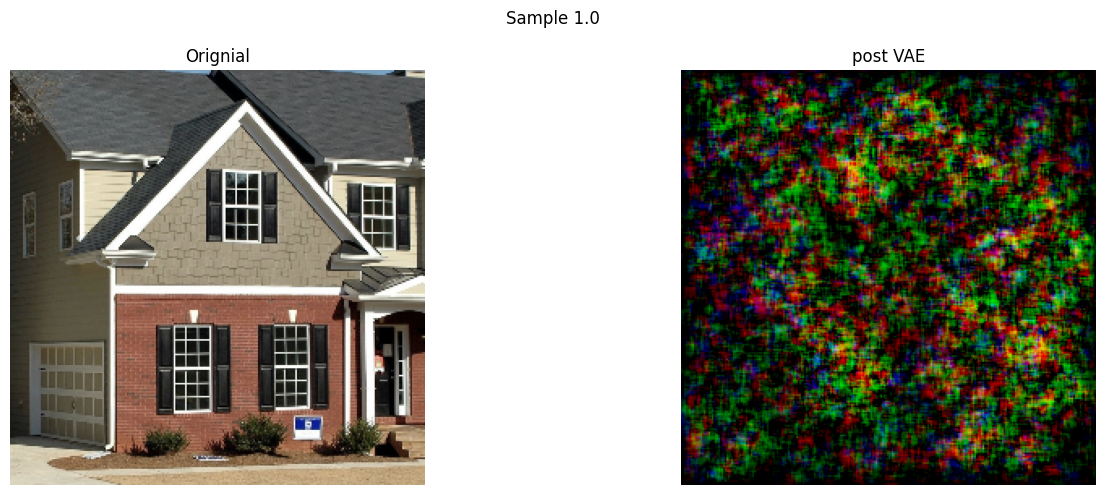

In [7]:
sample = next(iter(dataloader))

img       = sample[0][0].permute(1, 2, 0).cpu().numpy()
noisy_img = sample[1][0].permute(1, 2, 0).cpu().numpy()
noise     = sample[2][0].permute(1, 2, 0).cpu().numpy()

t = sample[3][0].item()
number = sample[4][0].item()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].imshow(img)
ax[0].set_title("Orignial")
ax[0].axis("off")


tensor_img = torch.tensor(img).permute(-1,0,1).unsqueeze(0)
recon_grid, mu, logvar = vae(tensor_img)
plt_recon_img = recon_grid[0].permute(1,2,0).cpu().detach().numpy()

ax[1].imshow(plt_recon_img)
ax[1].set_title("post VAE")
ax[1].axis("off")

plt.suptitle(f"Sample {number}")
plt.tight_layout()
plt.show()

# Diffusion model

In [8]:
dit = DiT(d_model        = 768,
          channels       = 4,
          grid_size      = 32,
          patch_size     = 2,
          timestep_freq  = 128,
          num_freq       = 128,
          num_DiT_blocks = 12,
          num_heads      = 12)



In [9]:
sample = next(iter(dataloader))

img       = sample[0][0].permute(1, 2, 0).cpu().numpy()
noisy_img = sample[1][0].permute(1, 2, 0).cpu().numpy()
noise     = sample[2][0].permute(1, 2, 0).cpu().numpy()


In [10]:
def training_step(model, vae, images, numbers, scheduler):
    """
    images:  [B, 3, H, W]
    numbers: [B,]
    """
    with torch.no_grad():
        with torch.no_grad():
            mu, logvar = vae.encode(images)
            z = vae.reparameterize(mu, logvar)

    B = z.shape[0]

    t = torch.randint(0, scheduler.max_timesteps, (z.shape[0],), device=z.device)
    x_t, noise = scheduler.add_noise(z, t)

    noise_pred = model(x_t, t.float(), numbers.to(z.device))
    return torch.nn.functional.mse_loss(noise_pred, noise)

In [ ]:
def train_dit(model: DiT, vae: VAE, dataloader, scheduler: DDPM, epochs = 10, lr=1e-4, device="cuda", freeze_VAE: bool = True):
    model.to(device)
    vae.to(device)

    # Freeze VAE
    if freeze_VAE:
        vae.eval()
        for p in vae.parameters():
            p.requires_grad = False

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr
    )

    losses = []

    for epoch in range(epochs):

        model.train()
        epoch_loss = 0.0

        for images, _, _, _, numbers in dataloader:

            images = images.to(device)
            numbers = numbers.float().to(device)

            with torch.no_grad():
                mu, logvar = vae.encode(images)
                z = vae.reparameterize(mu, logvar)

            B = z.shape[0]

            t = torch.randint(0, scheduler.max_timesteps, (B,),device=device)

            x_t, noise = scheduler.add_noise(z, t)

            noise_pred = model(x_t, t.float(), numbers)

            loss = torch.nn.functional.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"Loss: {avg_loss:.6f}"
        )

    return losses

In [11]:
ddpm = DDPM(betas_start = 1e-4, betas_end = 1e-2, max_timesteps = 1000)

In [12]:
training_step(dit, vae, sample[0], sample[4], ddpm)

tensor(0.9944, grad_fn=<MseLossBackward0>)

In [ ]:
@torch.no_grad()
def sample(model, vae: VAE, n_value, scheduler: DDPM, img_size = 256, device='cuda'):
    """Generate an image conditioned on a specific number."""

    # Start from pure noise
    x = torch.randn(1, 4, img_size // 8, img_size // 8, device=device)
    n = torch.tensor([n_value], dtype=torch.float32, device=device)

    for t in tqdm(reversed(range(scheduler.max_timesteps)), total=scheduler.max_timesteps):
        t_batch = torch.tensor([t], device=device)
        noise_pred = model(noisy_latent = x, time = t_batch, number = n)
        x = scheduler.remove_noise(xt    = x, 
                                   t     = t, 
                                   noise = noise_pred)

    # Decode latent -> image
    image = vae.decode(x)
    return image

In [15]:
ddpm = DDPM(betas_start = 1e-4, betas_end = 1e-2, max_timesteps = 1000)

recon_img = sample(model     = dit,
                   vae       = vae,
                   n_value   = 2,
                   scheduler = ddpm,
                   img_size  = 256,
                   device    = "cpu"
                   )

1000it [01:56,  8.59it/s]


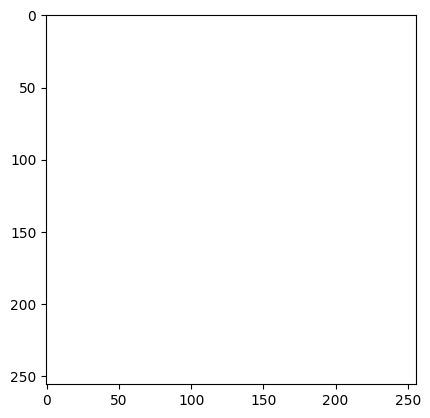

In [18]:
plt.imshow(recon_img[0].permute(1, 2, 0).cpu().numpy())